# Day 1 — Understanding RAG Concepts and Embeddings

## Goal

The goal of this notebook is to understand how text embeddings work and how they can be used to search for semantically related text.

In this task, we will:

1. Create short text documents.
2. Generate embeddings for each document.
3. Compare the similarity between documents.
4. Visualize the similarity scores.
5. Test a simple semantic search query.

## Why this matters

Embeddings are the foundation of Retrieval-Augmented Generation (RAG). They allow a system to search documents by meaning, not only by exact keywords.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully.")

c:\Users\homam\OneDrive\Desktop\intern-bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


## Step 1 — Create Sample Documents

In this step, we create a few short text documents.

These documents represent the information that our system can search through.

Later, we will convert these documents into embeddings so the computer can compare their meanings.

In [2]:
documents = [
    "RAG helps language models answer questions using external documents.",
    "Embeddings convert text into numerical vectors that represent meaning.",
    "Vector search finds documents that are semantically similar to a query.",
    "PostgreSQL is a relational database used to store structured data.",
    "FastAPI is a Python framework used to build APIs.",
    "Machine learning models learn patterns from data to make predictions.",
    "Customer feedback can be summarized to identify common issues.",
    "A refund policy explains when customers can return a product."
]

for i, doc in enumerate(documents, start=1):
    print(f"Document {i}: {doc}")

Document 1: RAG helps language models answer questions using external documents.
Document 2: Embeddings convert text into numerical vectors that represent meaning.
Document 3: Vector search finds documents that are semantically similar to a query.
Document 4: PostgreSQL is a relational database used to store structured data.
Document 5: FastAPI is a Python framework used to build APIs.
Document 6: Machine learning models learn patterns from data to make predictions.
Document 7: Customer feedback can be summarized to identify common issues.
Document 8: A refund policy explains when customers can return a product.


## Step 2 — Generate Text Embeddings

In this step, we use a sentence-transformer model to convert each text document into an embedding.

An embedding is a numerical representation of text meaning.

Documents with similar meanings should have similar embedding vectors.

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(documents)

print("Number of documents:", len(documents))
print("Embedding shape:", embeddings.shape)

c:\Users\homam\OneDrive\Desktop\intern-bootcamp\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\homam\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5008.73it/s]


Number of documents: 8
Embedding shape: (8, 384)


## Step 3 — Calculate Similarity Between Documents

In this step, we calculate cosine similarity between all document embeddings.

Cosine similarity helps us measure how close the meanings of two documents are.

A score closer to 1 means the documents are more semantically related.

In [4]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"Doc {i+1}" for i in range(len(documents))],
    columns=[f"Doc {i+1}" for i in range(len(documents))]
)

similarity_df

,Doc 1,Doc 2,Doc 3,Doc 4,Doc 5,Doc 6,Doc 7,Doc 8
Doc 1,1.000001,0.367534,0.362772,0.157529,0.207276,0.246374,0.244858,0.089571
Doc 2,0.367534,1.000000,0.376274,0.121277,0.027947,0.214359,0.125618,0.044812
Doc 3,0.362772,0.376274,1.000000,0.249483,0.103606,0.215485,0.140946,0.094776
Doc 4,0.157529,0.121277,0.249483,1.000000,0.155826,0.135742,0.144355,0.046150
Doc 5,0.207276,0.027947,0.103606,0.155826,1.000000,0.046729,0.023271,0.005406
Doc 6,0.246374,0.214359,0.215485,0.135742,0.046729,1.000000,0.164543,0.195071
Doc 7,0.244858,0.125618,0.140946,0.144355,0.023271,0.164543,1.000000,0.294266
Doc 8,0.089571,0.044812,0.094776,0.046150,0.005406,0.195071,0.294266,1.000000


## Step 4 — Visualize Similarity Matrix

In this step, we visualize the cosine similarity matrix using a heatmap.

The heatmap makes it easier to see which documents are more related to each other.

Darker or stronger areas usually mean higher similarity.

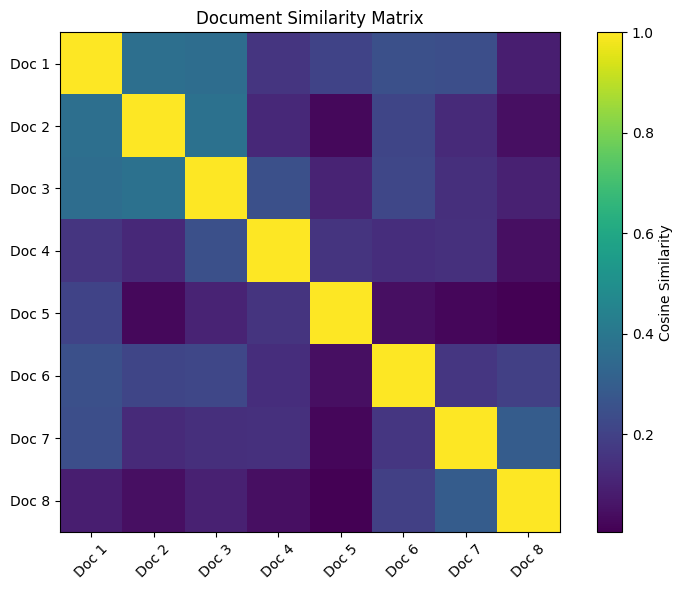

In [5]:
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine Similarity")

plt.xticks(
    ticks=range(len(documents)),
    labels=[f"Doc {i+1}" for i in range(len(documents))],
    rotation=45
)

plt.yticks(
    ticks=range(len(documents)),
    labels=[f"Doc {i+1}" for i in range(len(documents))]
)

plt.title("Document Similarity Matrix")
plt.tight_layout()
plt.show()

## Step 5 — Semantic Search Query

In this step, we test a simple semantic search.

We write a query, convert it into an embedding, compare it with the document embeddings, and retrieve the most similar document.

This is the retrieval part of RAG.

In [6]:
query = "How can language models use external documents?"

query_embedding = model.encode([query])

query_similarities = cosine_similarity(query_embedding, embeddings)[0]

results_df = pd.DataFrame({
    "Document": [f"Doc {i+1}" for i in range(len(documents))],
    "Text": documents,
    "Similarity Score": query_similarities
})

results_df = results_df.sort_values(by="Similarity Score", ascending=False)

results_df

,Document,Text,Similarity Score
0,Doc 1,RAG helps language models answer questions usi...,0.665841
1,Doc 2,Embeddings convert text into numerical vectors...,0.325670
5,Doc 6,Machine learning models learn patterns from da...,0.276824
2,Doc 3,Vector search finds documents that are semanti...,0.228576
3,Doc 4,PostgreSQL is a relational database used to st...,0.193918
7,Doc 8,A refund policy explains when customers can re...,0.121254
4,Doc 5,FastAPI is a Python framework used to build APIs.,0.114068
6,Doc 7,Customer feedback can be summarized to identif...,0.098165


## Step 6 — Create a Reusable Semantic Search Function

In this step, we create a function that can search the documents using any user question.

The function converts the question into an embedding, compares it with all document embeddings, and returns the most similar documents.

This makes the retrieval process reusable.

In [7]:
def semantic_search(query, top_k=3):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, embeddings)[0]

    results = pd.DataFrame({
        "Document": [f"Doc {i+1}" for i in range(len(documents))],
        "Text": documents,
        "Similarity Score": scores
    })

    results = results.sort_values(by="Similarity Score", ascending=False)

    return results.head(top_k)

In [8]:
semantic_search("How do embeddings represent text meaning?")

,Document,Text,Similarity Score
1,Doc 2,Embeddings convert text into numerical vectors...,0.813344
0,Doc 1,RAG helps language models answer questions usi...,0.331087
2,Doc 3,Vector search finds documents that are semanti...,0.288835


In [9]:
semantic_search("How can I build an API in Python?")

,Document,Text,Similarity Score
4,Doc 5,FastAPI is a Python framework used to build APIs.,0.620147
0,Doc 1,RAG helps language models answer questions usi...,0.154331
5,Doc 6,Machine learning models learn patterns from da...,0.083631


## Step 7 — Interactive Query Search

In this step, we allow the user to type a question.

The notebook will compare the question with all stored document embeddings and return the most relevant documents.

This simulates the retrieval step in a RAG system.

In [ ]:
user_query = input("what is rag used for: ")

semantic_search(user_query, top_k=3)